In [1]:
"""
Script to visualize pseudobulk splicing PSI data from the long format file
"""

# Load packages we need
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Set, Dict, Any, Optional
from scipy import stats
from sklearn.decomposition import PCA
import gffutils
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper # type: ignore
from leafletfa_utils.atseviz.main import * # type: ignore
print("Imports successful!")

# ----- Configuration -----

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Output directory
output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Timestamp for file naming
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!
Output directory: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations


In [2]:
# ----- Load data -----
pseudobulk_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/pseudobulk_final_tissue_celltype_aligned_20260105_170740.csv.gz"
print(f"Loading pseudobulk data from: {pseudobulk_file}")
long_df = pd.read_csv(pseudobulk_file, low_memory=False)
print(f"Loaded {len(long_df)} rows of data with {long_df['cell_type'].nunique()} cell types")

# Load ATSE data
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/HUMAN_FOUNDATION_ATSE_FILE_unanno_also_2025-09-21_05-02-35.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"Loaded {len(atses)} rows of ATSE data with {len(atses['event_id'].unique())} unique events")

db_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/paper_figures/isoform_gazers/long_read_hg38.db"
db = gffutils.FeatureDB(db_file, keep_order=True)
genome_db_available = True

Loading pseudobulk data from: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/pseudobulk_final_tissue_celltype_aligned_20260105_170740.csv.gz
Loaded 30105452 rows of data with 243 cell types
Loaded 160252 rows of ATSE data with 41489 unique events


In [3]:
long_df["junction_id"].nunique()

123383

#### Input: Gene ID or symbol and output: Clustermap output with all gene-junctions-ATSEs displayed PSI by major cell type group

In [4]:
# filter rows where n_cells==0
long_df = long_df[long_df["n_cells"] > 0]

# filter rows where gene_symbol is NaN
long_df = long_df[long_df["gene_symbol"].notna()]

In [5]:
long_df["gene_id"] = long_df["gene_id"].str.split(".").str[0]

In [9]:
long_df["cell_type"].nunique(), long_df["junction_id"].nunique(), long_df["gene_id"].nunique()

(117, 123383, 11470)

                         cell_type                junction_id  \
8175711              Kidney_B_Cell  chr11_64635452_64642538_-   
8175712             Fat_Fibroblast  chr11_64635452_64648218_-   
8175713           Thymus_SmoothMus  chr11_64635452_64648218_-   
8175714                     Fat_NK  chr11_64635452_64648218_-   
8175722  Salivary_Gland_Epithelial  chr11_64635452_64642538_-   
...                            ...                        ...   
8177646             Brain_In-Lamp5  chr11_64608082_64608563_-   
8177647             Fat_Fibroblast  chr11_64607500_64620293_-   
8177648         Vasculature_T_Cell  chr11_64607500_64620293_-   
8177651         Vasculature_T_Cell  chr11_64608082_64608563_-   
8177655            Limb_Muscle_APC  chr11_64608082_64620293_-   

         junction_id_index  junction_count  atse_count gene_symbol       psi  \
8175711               9355             0.0         0.0       NRXN2       NaN   
8175712               9356             0.0         0.0     

/scratch/ipykernel_2765730/3391548829.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis').copy()


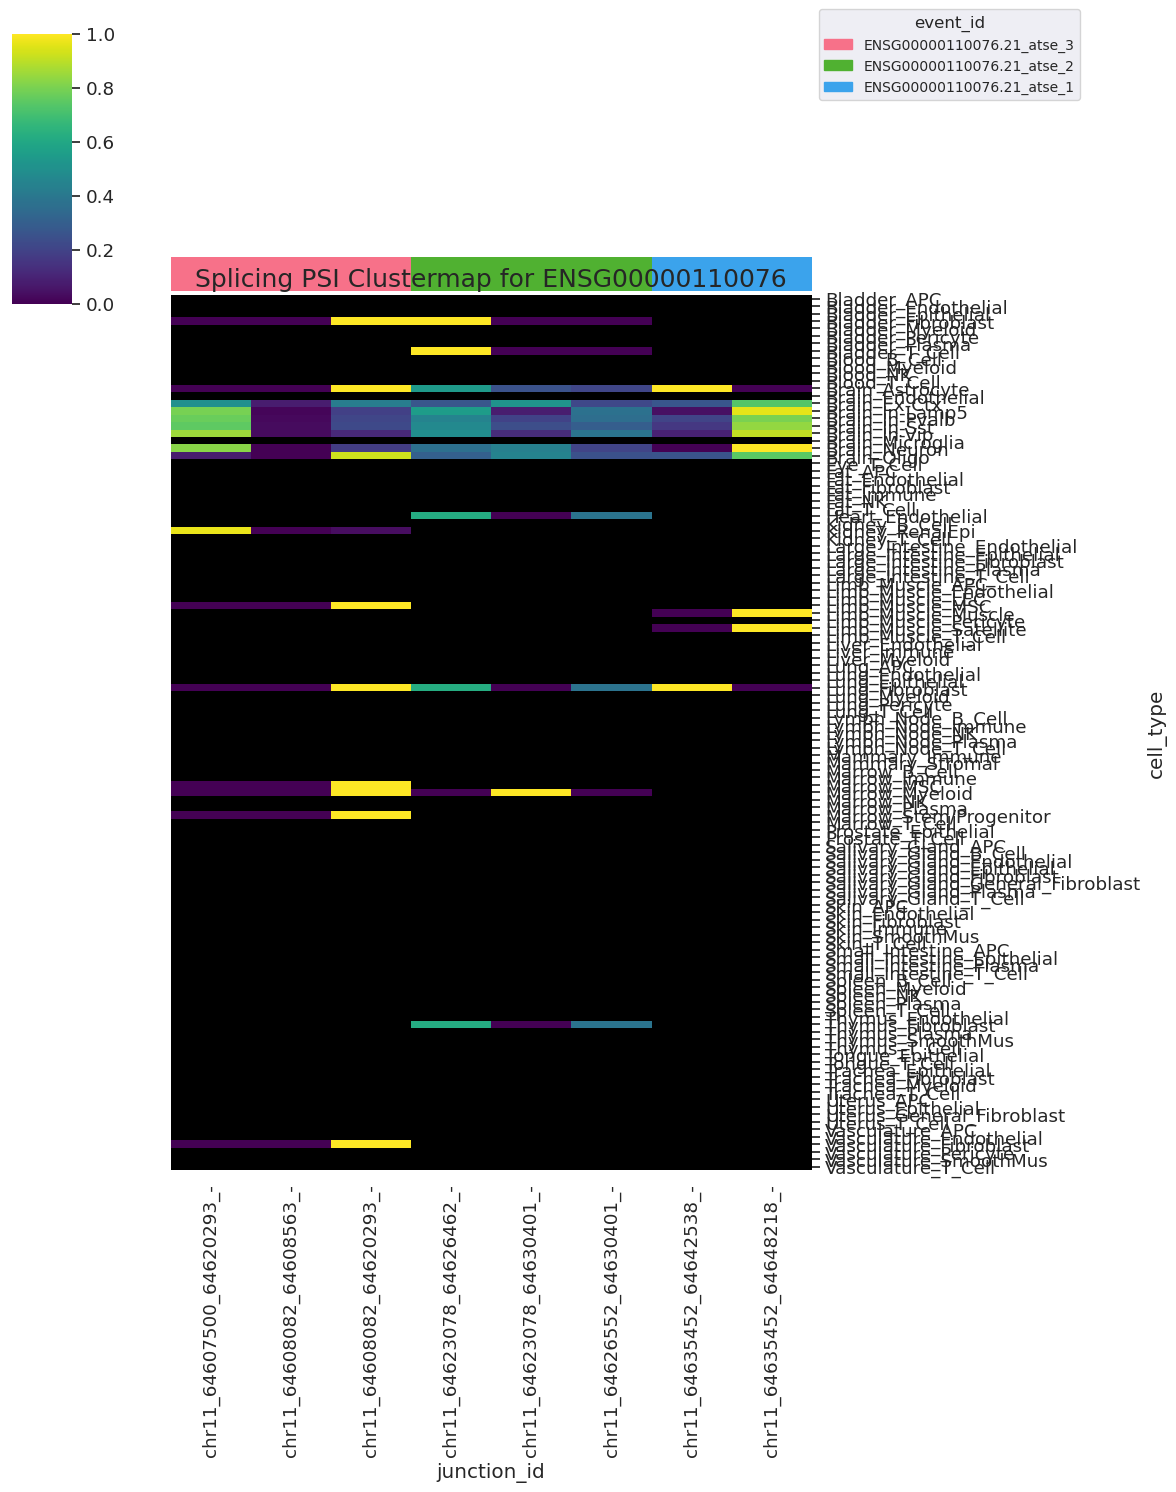

In [7]:
# Sample gene name from your dataset
# gene_name = np.random.choice(long_df["gene_symbol"].unique(), 1)[0]
gene_id = "ENSG00000110076"
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# --- Leave NaNs as they are, do not fill with 0 ---
# psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# --- Get the colormap and set the color for NaN values ---
# By default, seaborn uses the 'viridis' colormap. We'll make a copy and modify it.
# You can replace 'viridis' with any other colormap you prefer.
cmap = cm.get_cmap('viridis').copy()
cmap.set_bad('black')

# Generate the clustermap
g = sns.clustermap(
    psi_matrix,
    row_cluster=False,
    col_cluster=False,
    cmap=cmap,  # Use the modified colormap
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()

                         cell_type                junction_id  \
8175711              Kidney_B_Cell  chr11_64635452_64642538_-   
8175712             Fat_Fibroblast  chr11_64635452_64648218_-   
8175713           Thymus_SmoothMus  chr11_64635452_64648218_-   
8175714                     Fat_NK  chr11_64635452_64648218_-   
8175722  Salivary_Gland_Epithelial  chr11_64635452_64642538_-   
...                            ...                        ...   
8177646             Brain_In-Lamp5  chr11_64608082_64608563_-   
8177647             Fat_Fibroblast  chr11_64607500_64620293_-   
8177648         Vasculature_T_Cell  chr11_64607500_64620293_-   
8177651         Vasculature_T_Cell  chr11_64608082_64608563_-   
8177655            Limb_Muscle_APC  chr11_64608082_64620293_-   

         junction_id_index  junction_count  atse_count gene_symbol       psi  \
8175711               9355             0.0         0.0       NRXN2       NaN   
8175712               9356             0.0         0.0     

/scratch/ipykernel_2765730/1567874773.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis').copy()


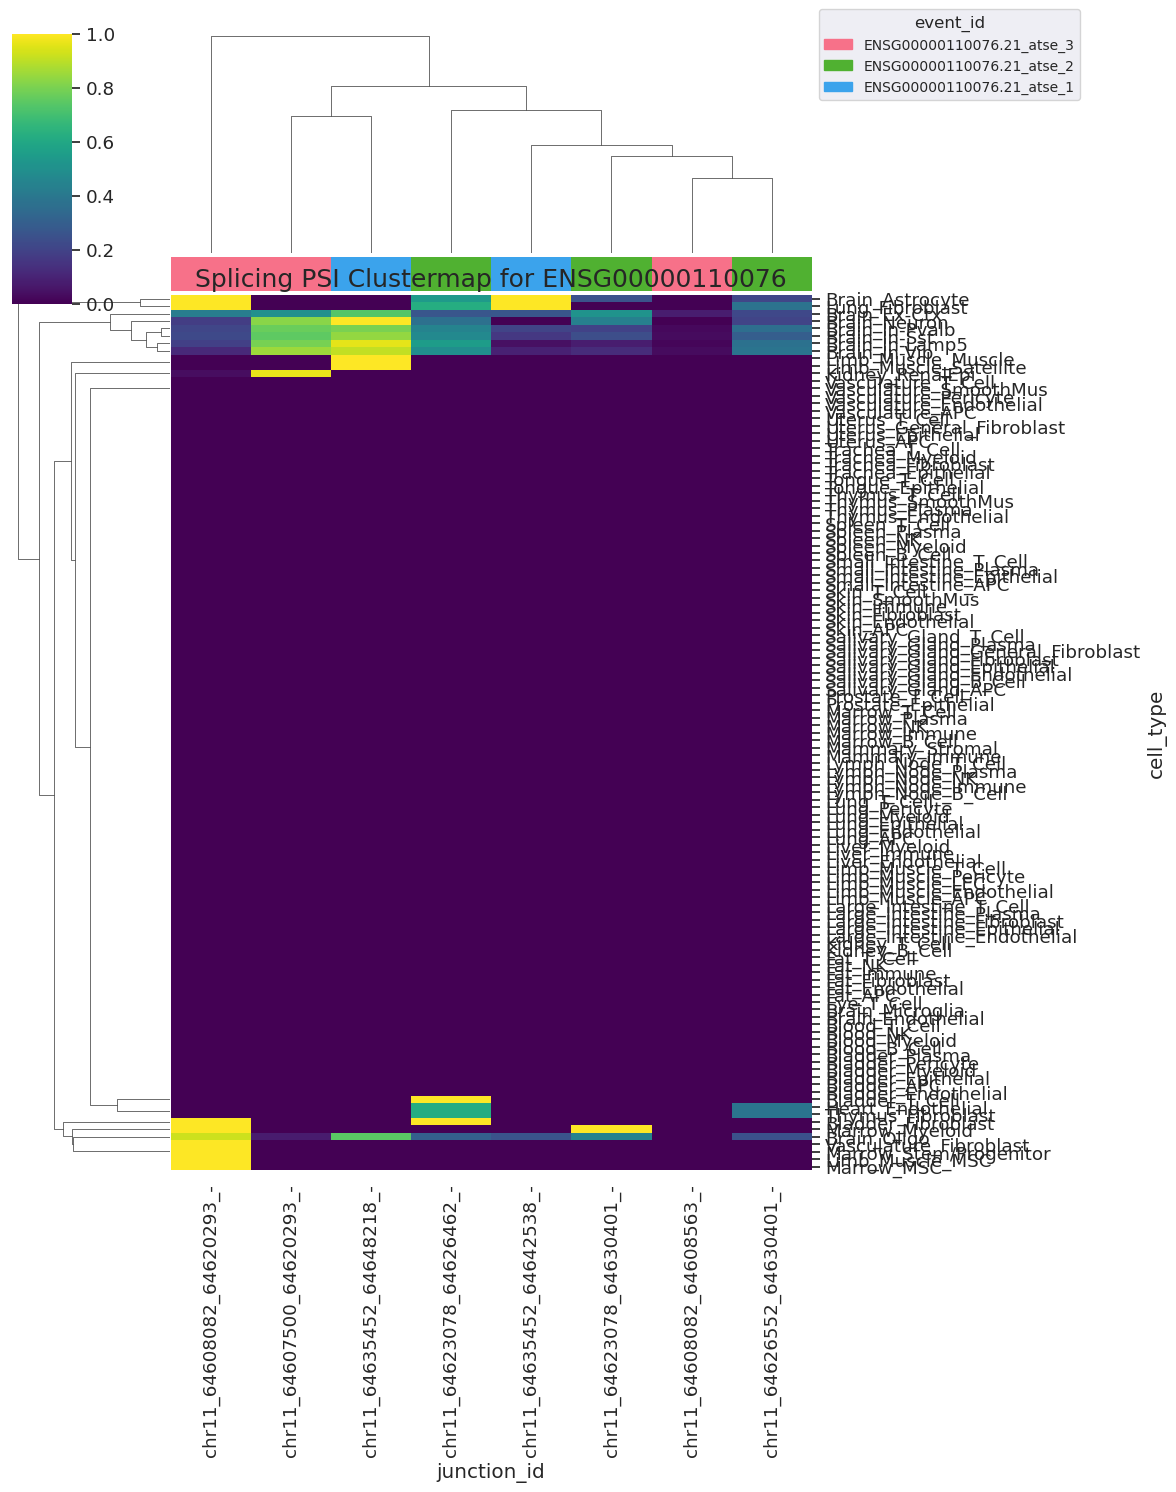

In [8]:
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# Fill NaNs with 0
psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# Get the colormap
cmap = cm.get_cmap('viridis').copy()

# Generate the clustermap WITH CLUSTERING
g = sns.clustermap(
    psi_matrix,
    row_cluster=True,  # Enable clustering
    col_cluster=True,  # Enable clustering
    cmap=cmap,
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()